## ==========================================
## ZATCH REEL RECOMMENDATION ENGINE
## NOTEBOOK 02 : MODEL TRAINING
## ==========================================

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pickle

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
DATA_PATH = r"E:\zatch-reel-recommendation\data\processed"

print("Path Configured")

Path Configured


In [3]:
bits_df = pd.read_csv(
    rf"{DATA_PATH}\bits_cleaned.csv"
)

users_df = pd.read_csv(
    rf"{DATA_PATH}\users_cleaned.csv"
)

interaction_df = pd.read_csv(
    rf"{DATA_PATH}\interaction_dataset.csv"
)

reel_features = pd.read_csv(
    rf"{DATA_PATH}\reel_features.csv"
)

user_features = pd.read_csv(
    rf"{DATA_PATH}\user_features.csv"
)

print("Datasets Loaded")

Datasets Loaded


In [4]:
print("Bits:", bits_df.shape)

print("Users:", users_df.shape)

print("Interactions:", interaction_df.shape)

print("Reel Features:", reel_features.shape)

print("User Features:", user_features.shape)

Bits: (87, 30)
Users: (141, 39)
Interactions: (1659, 13)
Reel Features: (87, 8)
User Features: (141, 8)


In [5]:
print(bits_df.columns.tolist())

['_id', 'title', 'description', 'video', 'thumbnail', 'hashtags', 'products', 'userId', 'likes', 'likeCount', 'shareLink', 'viewCount', 'shareCount', 'revenue', 'orders', 'isActive', 'comments', 'createdAt', '__v', 'isTrending', 'product_count', 'likes_count_actual', 'comments_count_actual', 'created_year', 'created_month', 'created_day', 'bitId', 'total_views', 'avg_engagement', 'reel_popularity_score']


In [6]:
bits_df[
    [
        "title",
        "description",
        "hashtags"
    ]
].head()

,title,description,hashtags
0,Italian pants,Italian pants,"['#pants', '#italian', '#style']"
1,Turtleneck shirts,NaN,"['#turtleneck', '#fashion', '#men']"
2,Leather jacket,NaN,"['#jacket', '#fashion', '#style']"
3,Accessories u may like,new,"['Fashion', 'art', 'new']"
4,Accessories u may like,new,"['Fashion', 'art', 'new']"


### Missing values check.

In [7]:
bits_df[
    [
        "title",
        "description",
        "hashtags"
    ]
].isnull().sum()

title          0
description    5
hashtags       0
dtype: int64

In [8]:
bits_df["description"] = (
    bits_df["description"]
    .fillna("")
)

bits_df["content"] = (
    bits_df["title"].astype(str)
    + " "
    + bits_df["description"].astype(str)
    + " "
    + bits_df["hashtags"].astype(str)
)

print("Content Feature Created")

Content Feature Created


In [9]:
bits_df[
    [
        "title",
        "content"
    ]
].head()

,title,content
0,Italian pants,"Italian pants Italian pants ['#pants', '#itali..."
1,Turtleneck shirts,"Turtleneck shirts ['#turtleneck', '#fashion',..."
2,Leather jacket,"Leather jacket ['#jacket', '#fashion', '#style']"
3,Accessories u may like,"Accessories u may like new ['Fashion', 'art', ..."
4,Accessories u may like,"Accessories u may like new ['Fashion', 'art', ..."


## TF-IDF Vectorization

In [10]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(
    bits_df["content"]
)

print(
    "TF-IDF Shape:",
    tfidf_matrix.shape
)

TF-IDF Shape: (87, 772)


In [11]:
indices = pd.Series(
    bits_df.index,
    index=bits_df["_id"]
).drop_duplicates()

print("Index Mapping Created")

Index Mapping Created


## Recommendation function.

In [12]:
def recommend_similar_reels(
    reel_id,
    top_n=5
):
    
    idx = indices[reel_id]

    sim_scores = list(
        enumerate(cosine_sim[idx])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:top_n+1]

    reel_indices = [
        i[0]
        for i in sim_scores
    ]

    return bits_df[
        [
            "_id",
            "title",
            "reel_popularity_score"
        ]
    ].iloc[reel_indices]

In [13]:
bits_df["_id"].iloc[0]

'698e30532c63bfbc04769c5e'

In [14]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(
    bits_df["content"]
)

print(
    "TF-IDF Shape:",
    tfidf_matrix.shape
)

TF-IDF Shape: (87, 772)


In [15]:
cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

print(
    "Cosine Matrix Shape:",
    cosine_sim.shape
)

Cosine Matrix Shape: (87, 87)


In [16]:
recommend_similar_reels(
    "698e30532c63bfbc04769c5e"
)

,_id,title,reel_popularity_score
49,6a0c27f2cccd23326e8be29f,Mens formal shirts,23.302857
2,698e33892c63bfbc0476b11f,Leather jacket,NaN
67,6a1598534dfbf8e8d4fdb4c1,Kota Style Hand Printed Cotton Sarees,30.213333
50,6a0c4c22d4f03db64a786e2d,shirst,24.372308
58,6a0eee72ed25ae0d7deabbfc,Texture Tees,33.396923


In [17]:
print(interaction_df.shape)

interaction_df.head()

(1659, 13)


,_id,userId,bitId,watchPercent,completedWatch,rewatched,replayCount,likedDuringWatch,sharedDuringWatch,addedToCart,watch_score,interaction_score,engagement_score
0,6a08bb67b7bb9861659c3e29,69f8608068f7e97ef44183e4,6a08bb2eb7bb9861659c3e06,0,False,False,0,False,True,False,0.0,15,15.0
1,6a0d9d87d4f03db64a7921bf,6a084ac71a9ba20ae97f5f37,6a0c58c8d4f03db64a788ccd,0,False,False,0,False,True,False,0.0,15,15.0
2,6a0d9d88d4f03db64a7921c4,6a084ac71a9ba20ae97f5f37,6a0c58c8d4f03db64a788ccd,0,False,False,0,False,True,False,0.0,15,15.0
3,6a0ff9a4fac84b0b7fb94d91,698e259d2c63bfbc04768479,6a0efe70c5a9d08fea4c67cf,0,False,False,0,False,False,False,0.0,0,0.0
4,6a0ff9a5fac84b0b7fb94d99,698e259d2c63bfbc04768479,6a0febf65ecfbb647dcf6c6f,0,False,False,0,False,False,False,0.0,0,0.0


In [18]:
interaction_df["engagement_score"].describe()

count    1659.000000
mean       28.408559
std        15.682849
min         0.000000
25%        17.200000
50%        26.600000
75%        33.000000
max       125.000000
Name: engagement_score, dtype: float64

<Axes: >

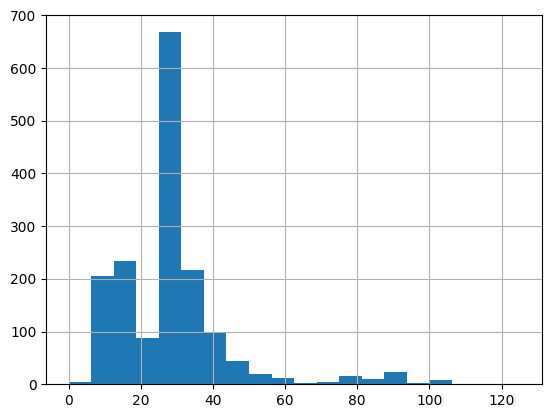

In [19]:
interaction_df["engagement_score"].hist(
    bins=20
)

## Collaborative Filtering

In [20]:
print(
    "Unique Users:",
    interaction_df["userId"].nunique()
)

print(
    "Unique Reels:",
    interaction_df["bitId"].nunique()
)

Unique Users: 52
Unique Reels: 78


In [21]:
user_reel_matrix = interaction_df.pivot_table(
    index="userId",
    columns="bitId",
    values="engagement_score",
    fill_value=0
)

print(
    user_reel_matrix.shape
)

(52, 78)


In [22]:
user_reel_matrix.head()

bitId,69a69a9d0a0ce3fd3a6cae83,69aac90f4e2d6530993b50a6,69b517aff10cd924f53e68b3,69b99950d5ba7b8d34df55f8,69b99b08d5ba7b8d34df5cb3,69b99c44d5ba7b8d34df60eb,69b99fbed5ba7b8d34df68c7,69b9a3d2d5ba7b8d34df6f90,69e38343330134cd220d9c20,69e73c9ee9d9e96620249058,...,6a1da3ea61d3ca2f14751546,6a1da45861d3ca2f14751bce,6a1daccb61d3ca2f147522ed,6a1ea1416728afd227b9fa38,6a22db91ad7941493646e922,6a22df48ad7941493646eafb,6a22e0b0ad7941493646ed22,6a22ed04ad7941493646f243,6a22ee04ad7941493646f337,6a254e2f9984a0ae2e2cd4fc
userId,,,,,,,,,,,,,,,,,,,,,
698e25132c63bfbc047683d8,0.000000,0.0,0.000000,0.00,0.000000,11.600000,0.000000,0.000000,0.000000,0.00,...,0.0,0.0,0.0,0.000000,0.0,0.00,0.0,0.0,0.0,0.0
698e259d2c63bfbc04768479,36.682353,26.4,35.220000,34.38,24.622222,38.285714,35.714286,36.325000,23.866667,30.42,...,19.7,20.9,0.0,18.000000,20.0,30.45,26.9,0.0,22.5,18.0
698e263e2c63bfbc0476857e,22.933333,0.0,33.333333,18.90,29.485714,21.300000,24.950000,24.500000,0.000000,30.25,...,19.5,36.0,52.2,26.400000,0.0,0.00,0.0,0.0,0.0,0.0
698e264a2c63bfbc04768582,28.800000,0.0,0.000000,0.00,0.000000,0.000000,0.000000,13.200000,0.000000,0.00,...,0.0,0.0,0.0,0.000000,0.0,0.00,0.0,0.0,0.0,0.0
698e269c2c63bfbc04768709,16.000000,0.0,12.400000,0.00,18.500000,0.000000,0.000000,26.666667,0.000000,11.60,...,19.1,16.8,0.0,25.066667,11.6,22.70,27.3,0.0,69.6,0.0


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(
    user_reel_matrix
)

print(
    user_similarity.shape
)

(52, 52)


In [24]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_reel_matrix.index,
    columns=user_reel_matrix.index
)

user_similarity_df.head()

userId,698e25132c63bfbc047683d8,698e259d2c63bfbc04768479,698e263e2c63bfbc0476857e,698e264a2c63bfbc04768582,698e269c2c63bfbc04768709,698e6cbe2c63bfbc0476bfa7,69902d022c63bfbc0476da36,6992fed22c63bfbc04771576,699a2e703ec6020eaac62877,699db7d01efc346e038a285b,...,6a26e97e9984a0ae2e2d540d,6a26e9ca9984a0ae2e2d5691,6a26f1d59984a0ae2e2d6b5d,6a26f1fa9984a0ae2e2d6c36,6a26f5d79984a0ae2e2d77e3,6a26f7109984a0ae2e2d840b,6a2701259984a0ae2e2d90e4,6a2724639984a0ae2e2da2b1,6a273e239984a0ae2e2da9c9,6a276f249984a0ae2e2dac00
userId,,,,,,,,,,,,,,,,,,,,,
698e25132c63bfbc047683d8,1.000000,0.151246,0.106044,0.000000,0.000000,0.131952,0.000000,0.000000,0.142405,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
698e259d2c63bfbc04768479,0.151246,1.000000,0.817661,0.277622,0.650191,0.727949,0.451073,0.117170,0.717710,0.272456,...,0.316509,0.169463,0.198857,0.259085,0.287726,0.151032,0.181712,0.198246,0.357038,0.186338
698e263e2c63bfbc0476857e,0.106044,0.817661,1.000000,0.240427,0.516297,0.663083,0.396408,0.098078,0.700016,0.286697,...,0.279659,0.154760,0.271411,0.300626,0.260981,0.140186,0.186126,0.226379,0.438404,0.120174
698e264a2c63bfbc04768582,0.000000,0.277622,0.240427,1.000000,0.125910,0.199789,0.138280,0.000000,0.069916,0.042457,...,0.219376,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
698e269c2c63bfbc04768709,0.000000,0.650191,0.516297,0.125910,1.000000,0.435067,0.288271,0.139442,0.449765,0.124199,...,0.223211,0.125843,0.093686,0.167747,0.230430,0.036455,0.042387,0.177442,0.140640,0.052670


## User Recommendation Function

In [25]:
def recommend_for_user(
    user_id,
    top_n=5
):

    similar_users = user_similarity_df[
        user_id
    ].sort_values(
        ascending=False
    )

    similar_users = similar_users.iloc[1:6]

    watched_reels = set(
        interaction_df[
            interaction_df["userId"] == user_id
        ]["bitId"]
    )

    recommendations = {}

    for sim_user, similarity_score in similar_users.items():

        sim_user_reels = interaction_df[
            interaction_df["userId"] == sim_user
        ]

        for _, row in sim_user_reels.iterrows():

            reel_id = row["bitId"]

            if reel_id not in watched_reels:

                recommendations[reel_id] = (
                    recommendations.get(reel_id, 0)
                    + similarity_score
                    * row["engagement_score"]
                )

    recommendations = sorted(
        recommendations.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return recommendations[:top_n]

In [26]:
interaction_df["userId"].iloc[0]

'69f8608068f7e97ef44183e4'

In [27]:
recommend_for_user(
    "69f8608068f7e97ef44183e4"
)

[('6a0efe70c5a9d08fea4c67cf', 752.6783250140707),
 ('6a0c5c48d4f03db64a78945a', 655.207144286456),
 ('6a189f6efcdbfad047e3fc69', 484.69453543360885),
 ('6a0c158bb10aa6108036df86', 477.5298970464352),
 ('6a0edae6ed25ae0d7deab2c8', 371.42766184211985)]

In [28]:
recommended_reels = recommend_for_user(
    interaction_df["userId"].iloc[0]
)

recommended_reels

[('6a0efe70c5a9d08fea4c67cf', 752.6783250140707),
 ('6a0c5c48d4f03db64a78945a', 655.207144286456),
 ('6a189f6efcdbfad047e3fc69', 484.69453543360885),
 ('6a0c158bb10aa6108036df86', 477.5298970464352),
 ('6a0edae6ed25ae0d7deab2c8', 371.42766184211985)]

## Showing Reel Titles Instead of IDs

In [29]:
def get_user_recommendations(
    user_id,
    top_n=5
):

    recommendations = recommend_for_user(
        user_id,
        top_n
    )

    reel_ids = [
        x[0]
        for x in recommendations
    ]

    result = bits_df[
        bits_df["_id"].isin(reel_ids)
    ][
        [
            "_id",
            "title",
            "reel_popularity_score"
        ]
    ]

    return result

In [30]:
get_user_recommendations(
    "69f8608068f7e97ef44183e4"
)

,_id,title,reel_popularity_score
47,6a0c158bb10aa6108036df86,Shorts,30.721379
54,6a0c5c48d4f03db64a78945a,Red Crush Hamper,35.044706
57,6a0edae6ed25ae0d7deab2c8,Malai silk sarees,26.575000
60,6a0efe70c5a9d08fea4c67cf,Maheshwari silk sarees,38.016800
73,6a189f6efcdbfad047e3fc69,Substract the Mind,32.543784


## Item-Based Collaborative Filtering

In [32]:
interaction_matrix = interaction_df.pivot_table(
    index="userId",
    columns="bitId",
    values="engagement_score",
    fill_value=0
)

print(interaction_matrix.shape)

(52, 78)


In [33]:
item_user_matrix = interaction_matrix.T

print(item_user_matrix.shape)

(78, 52)


In [34]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(
    item_user_matrix
)

print(item_similarity.shape)

(78, 78)


In [35]:
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.head()

bitId,69a69a9d0a0ce3fd3a6cae83,69aac90f4e2d6530993b50a6,69b517aff10cd924f53e68b3,69b99950d5ba7b8d34df55f8,69b99b08d5ba7b8d34df5cb3,69b99c44d5ba7b8d34df60eb,69b99fbed5ba7b8d34df68c7,69b9a3d2d5ba7b8d34df6f90,69e38343330134cd220d9c20,69e73c9ee9d9e96620249058,...,6a1da3ea61d3ca2f14751546,6a1da45861d3ca2f14751bce,6a1daccb61d3ca2f147522ed,6a1ea1416728afd227b9fa38,6a22db91ad7941493646e922,6a22df48ad7941493646eafb,6a22e0b0ad7941493646ed22,6a22ed04ad7941493646f243,6a22ee04ad7941493646f337,6a254e2f9984a0ae2e2cd4fc
bitId,,,,,,,,,,,,,,,,,,,,,
69a69a9d0a0ce3fd3a6cae83,1.000000,0.371120,0.367158,0.545600,0.443288,0.437474,0.722274,0.789406,0.371120,0.631505,...,0.498451,0.617470,0.298660,0.351237,0.274918,0.768159,0.285781,0.000000,0.574288,0.248266
69aac90f4e2d6530993b50a6,0.371120,1.000000,0.443104,0.582412,0.403749,0.533806,0.660261,0.359544,1.000000,0.389001,...,0.279845,0.234382,0.000000,0.174549,0.286150,0.593189,0.533769,0.000000,0.254515,0.668965
69b517aff10cd924f53e68b3,0.367158,0.443104,1.000000,0.660164,0.799669,0.792551,0.687977,0.476516,0.443104,0.572538,...,0.499315,0.357410,0.182384,0.322323,0.296112,0.331832,0.321024,0.196211,0.235599,0.296421
69b99950d5ba7b8d34df55f8,0.545600,0.582412,0.660164,1.000000,0.672082,0.841404,0.857136,0.457189,0.582412,0.768240,...,0.362006,0.265768,0.196253,0.183626,0.166657,0.345481,0.310874,0.000000,0.202700,0.389613
69b99b08d5ba7b8d34df5cb3,0.443288,0.403749,0.799669,0.672082,1.000000,0.741277,0.718974,0.493793,0.403749,0.682636,...,0.611515,0.473965,0.210275,0.339822,0.269216,0.373649,0.524776,0.141365,0.419053,0.270094


In [42]:
def similar_reels_item_based(
    reel_id,
    top_n=5
):

    if reel_id not in item_similarity_df.index:
        return f"Reel ID {reel_id} not found"

    similar_scores = item_similarity_df[
        reel_id
    ].sort_values(
        ascending=False
    )

    return similar_scores[
        1:top_n+1
    ]

In [43]:
item_similarity_df.index[:10]

Index(['69a69a9d0a0ce3fd3a6cae83', '69aac90f4e2d6530993b50a6',
       '69b517aff10cd924f53e68b3', '69b99950d5ba7b8d34df55f8',
       '69b99b08d5ba7b8d34df5cb3', '69b99c44d5ba7b8d34df60eb',
       '69b99fbed5ba7b8d34df68c7', '69b9a3d2d5ba7b8d34df6f90',
       '69e38343330134cd220d9c20', '69e73c9ee9d9e96620249058'],
      dtype='object', name='bitId')

In [44]:
similar_reels_item_based(
    "69a69a9d0a0ce3fd3a6cae83"
)

bitId
6a06c0371a9ba20ae97ce5be    0.814876
6a0812db1a9ba20ae97ecaa8    0.804951
69b9a3d2d5ba7b8d34df6f90    0.789406
6a0efe70c5a9d08fea4c67cf    0.784543
6a0823a91a9ba20ae97f0b3b    0.779271
Name: 69a69a9d0a0ce3fd3a6cae83, dtype: float64

# Hybrid Recommendation System

In [45]:
def hybrid_recommendation(
    user_id,
    reel_id,
    top_n=5
):

    content_recs = recommend_similar_reels(
        reel_id,
        top_n
    )

    user_recs = get_user_recommendations(
        user_id,
        top_n
    )

    item_recs = similar_reels_item_based(
        reel_id,
        top_n
    )

    return {
        "content_based": content_recs,
        "user_based": user_recs,
        "item_based": item_recs
    }

In [46]:
hybrid_result = hybrid_recommendation(
    "69f8608068f7e97ef44183e4",
    "69a69a9d0a0ce3fd3a6cae83"
)

In [47]:
hybrid_result.keys()

dict_keys(['content_based', 'user_based', 'item_based'])

In [48]:
hybrid_result["content_based"]

,_id,title,reel_popularity_score
62,6a101a44a9955ce94394ce5d,Trendy Plain Shirts,33.040000
59,6a0efbb6c5a9d08fea4c6025,Premium Checks Shirts,34.651000
11,69b8d57bd5ba7b8d34df0a7d,Buy 1 Get 1 Collections,NaN
49,6a0c27f2cccd23326e8be29f,Mens formal shirts,23.302857
48,6a0c1a49b10aa6108036e8d0,Mens Formal Trousers,23.738000


In [49]:
hybrid_result["user_based"]

,_id,title,reel_popularity_score
47,6a0c158bb10aa6108036df86,Shorts,30.721379
54,6a0c5c48d4f03db64a78945a,Red Crush Hamper,35.044706
57,6a0edae6ed25ae0d7deab2c8,Malai silk sarees,26.575000
60,6a0efe70c5a9d08fea4c67cf,Maheshwari silk sarees,38.016800
73,6a189f6efcdbfad047e3fc69,Substract the Mind,32.543784


In [50]:
hybrid_result["item_based"]

bitId
6a06c0371a9ba20ae97ce5be    0.814876
6a0812db1a9ba20ae97ecaa8    0.804951
69b9a3d2d5ba7b8d34df6f90    0.789406
6a0efe70c5a9d08fea4c67cf    0.784543
6a0823a91a9ba20ae97f0b3b    0.779271
Name: 69a69a9d0a0ce3fd3a6cae83, dtype: float64

# Model Evaluation

In [51]:
# BASIC MODEL STATISTICS

print("="*50)

print(
    "Total Users:",
    interaction_df["userId"].nunique()
)

print(
    "Total Reels:",
    interaction_df["bitId"].nunique()
)

print(
    "Total Interactions:",
    len(interaction_df)
)

print("="*50)

Total Users: 52
Total Reels: 78
Total Interactions: 1659


In [52]:
coverage = (
    interaction_df["bitId"].nunique()
    /
    len(bits_df)
) * 100

print(
    f"Catalog Coverage: {coverage:.2f}%"
)

Catalog Coverage: 89.66%


In [53]:
avg_interactions = (
    len(interaction_df)
    /
    interaction_df["userId"].nunique()
)

print(
    f"Average Interactions Per User: {avg_interactions:.2f}"
)

Average Interactions Per User: 31.90


In [54]:
print(
    "Content Similarity Matrix:",
    cosine_sim.shape
)

print(
    "User Similarity Matrix:",
    user_similarity.shape
)

print(
    "Item Similarity Matrix:",
    item_similarity.shape
)

Content Similarity Matrix: (87, 87)
User Similarity Matrix: (52, 52)
Item Similarity Matrix: (78, 78)


In [55]:
print(
    "HYBRID RECOMMENDATION SYSTEM READY"
)

HYBRID RECOMMENDATION SYSTEM READY


In [56]:
import pickle
import os

In [57]:
os.makedirs(
    "../models",
    exist_ok=True
)

print("Models Folder Ready")

Models Folder Ready


In [58]:
with open(
    "../models/content_similarity.pkl",
    "wb"
) as f:

    pickle.dump(
        cosine_sim,
        f
    )

print(
    "Content Similarity Saved"
)

Content Similarity Saved


In [59]:
with open(
    "../models/user_similarity.pkl",
    "wb"
) as f:

    pickle.dump(
        user_similarity,
        f
    )

print(
    "User Similarity Saved"
)

User Similarity Saved


In [60]:
with open(
    "../models/item_similarity.pkl",
    "wb"
) as f:

    pickle.dump(
        item_similarity,
        f
    )

print(
    "Item Similarity Saved"
)

Item Similarity Saved


In [61]:
with open(
    "../models/reel_indices.pkl",
    "wb"
) as f:

    pickle.dump(
        indices,
        f
    )

print(
    "Indices Saved"
)

Indices Saved


In [62]:
print(
    os.listdir("../models")
)

['content_similarity.pkl', 'item_similarity.pkl', 'reel_indices.pkl', 'user_similarity.pkl']


In [63]:
print("="*60)

print(
    "NOTEBOOK 02 COMPLETED SUCCESSFULLY"
)

print("="*60)

print(
    "Content-Based Model Ready"
)

print(
    "Collaborative Filtering Ready"
)

print(
    "Hybrid Recommendation System Ready"
)

print(
    "Models Saved Successfully"
)

print("="*60)

NOTEBOOK 02 COMPLETED SUCCESSFULLY
Content-Based Model Ready
Collaborative Filtering Ready
Hybrid Recommendation System Ready
Models Saved Successfully


In [64]:
import os

print(os.path.abspath("../models"))

D:\models
